In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"

In [2]:
import torch
import k3d
import numpy as np
import matplotlib.pyplot as plt
import pickle

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from models.wire import ConditionalWIRE 
from util.visualization.utils_mesh import get_mesh
from training.modular.residuals import ResidualLibrary, ResidualTerm, compute_loss

torch.manual_seed(0)

device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [6]:
losses_over_time_dict = {}
weights_over_time_dict = {}
times_dict = {}
mesh_dict = {}

# keys = ["Adam_nostrain_", "GN_nostrain_linesearch_", "GN_strain_linesearch", "Adam_strain", "GN_strain[1e-5]_linesearch", "Adam_strain[1e-5]"]
# keys = ["Adam_nostrain_", "GN_nostrain_linesearch_"] 
# keys = ["GN_strain_linesearch", "Adam_strain"] ## effectively no strain so not so interesting
# keys = ["GN_strain[1e-5]_linesearch", "Adam_strain[1e-5]"] ## same as next
# keys = ["GN_strain[1e-5]_ph0iso0.1_linesearch", "Adam_strain[1e-5]_ph0iso0.1"]
## 14.08
# keys = ["GN_ph0iso0.1_linesearch_pre_4096eik_drsdf", "Adam_ph0iso0.1_lr3e-4_pre_4096eik_drsdf"] ## GOOD
# keys = ["GN_strain[1e-5]_ph0iso0.1_linesearch_pre_4096eik_drsdf", "Adam_strain[1e-5]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf"] ## GOOD
keys = ["Adam_strain[1e-5,max100]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf", "Adam_strain[1e-5,max1000]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf"]
# keys = ["GN_strain[1e-5,max1000]_ph0iso0.1_linesearch_pre_4096eik_drsdf", "Adam_strain[1e-5,max1000]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf"] ## GOOD
# keys = ["GN_strain[1e-4,max1000]_ph0iso0.1_linesearch_pre_4096eik_drsdf", "Adam_strain[1e-4,max1000]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf"] ## GOOD

for key in keys:
    with open(f'{key}/losses_over_time.pkl', 'rb') as f:
        losses_over_time_dict[key] = pickle.load(f)

    with open(f'{key}/times.pkl', 'rb') as f:
        times_dict[key] = pickle.load(f)
        
    with open(f'{key}/weights_over_time.pkl', 'rb') as f:
        weights_over_time_dict[key] = pickle.load(f)

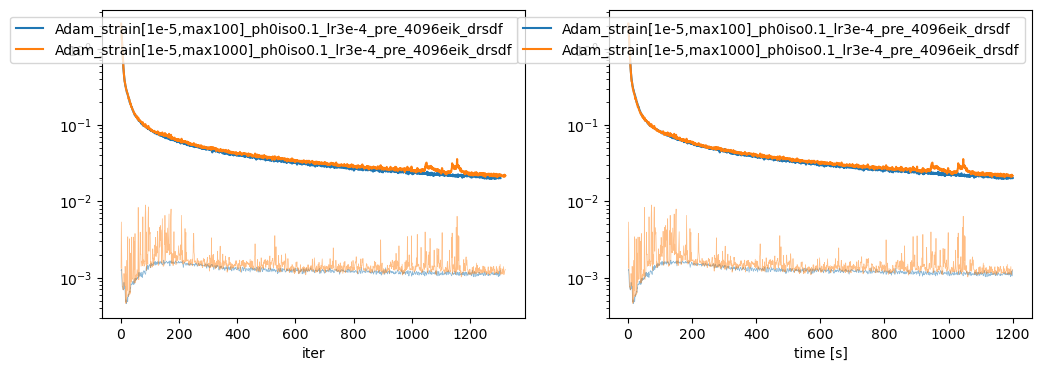

In [7]:
fig, axs = plt.subplots(1,2, figsize=(12,4))

for key in keys:
    losses_over_time = losses_over_time_dict[key]
    weights_over_time = weights_over_time_dict[key]
    times = times_dict[key]

    weighted_sum = np.sum([np.array(losses_over_time[k]) * np.array(weights_over_time[k]) for k in losses_over_time.keys()], axis=0)
    
    ## over iters
    axs[0].plot(weighted_sum, label=key)
    axs[0].legend()
    axs[0].set_xlabel("iter")
    axs[0].semilogy()

    ## over time
    axs[1].plot(times, weighted_sum, label=key)
    axs[1].legend()
    axs[1].set_xlabel("time [s]")
    axs[1].semilogy()
    
    
    k = "strain"
    # Use the same color as the weighted_sum line, but dotted
    color = axs[0].lines[-1].get_color()
    strain = np.array(losses_over_time[k]) * np.array(weights_over_time[k])
    axs[0].plot(strain, alpha=0.5, color=color, linewidth=0.5)
    axs[1].plot(times, strain, alpha=0.5, color=color, linewidth=0.5)

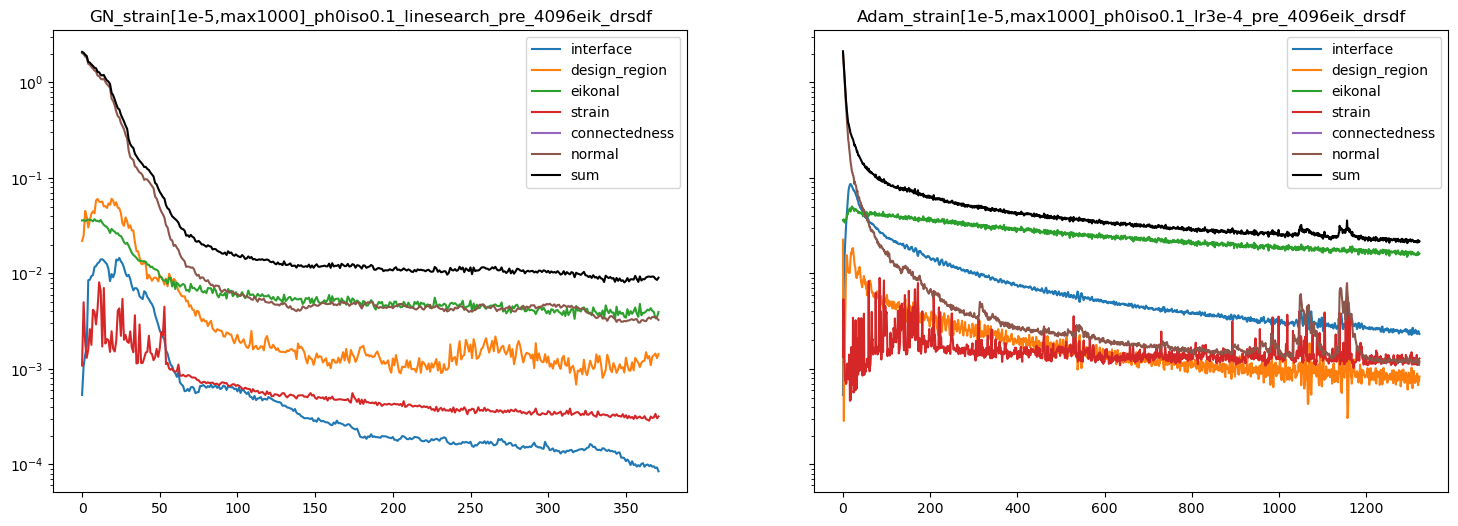

In [76]:
fig, axs = plt.subplots(1,2, figsize=(18,6), sharey=True)
for key, ax in zip(keys, axs):
    losses_over_time = losses_over_time_dict[key]
    weights_over_time = weights_over_time_dict[key]
    
    for k, v in losses_over_time.items():
        ax.plot(np.array(v)*np.array(weights_over_time[k]), label=k)
    weighted_sum = np.sum([np.array(losses_over_time[k]) * np.array(weights_over_time[k]) for k in losses_over_time.keys()], axis=0)
    ax.plot(weighted_sum, c='k', label="sum")
    ax.legend()
    ax.semilogy()
    ax.set_title(f"{key}")
plt.show()

### Plot shapes

In [48]:
model = ConditionalWIRE([4, 32, 32, 32, 1], False, 18, 1, 6)
key = keys[1]
model.load_state_dict(torch.load(f"{key}/model.pt", map_location=device))
print(key)
bounds = torch.from_numpy(np.load('../Data JEB/bounds.npy')).float()


model = model.double()
f = lambda x : model(x, 0.05+torch.zeros([len(x), 1], dtype=torch.float64) )
verts, faces = get_mesh(
    f, 
    N=128, 
    device=device,
    bbox_min=bounds[:,0],
    bbox_max=bounds[:,1],
    chunks=1
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
## with surface strain colormap
# from torch.func import vmap
# strains = vmap(res_lib._strain, in_dims=(None, 0))(params, torch.tensor(verts, dtype=torch.float64)).squeeze().detach().cpu()
# fig += k3d.mesh(verts, faces, attribute=strains.log(), side='double', flat_shading=False)

# fig += k3d.mesh(mesh_env.vertices, mesh_env.faces, color=0xbb0000, opacity=0.3)
# fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False, attribute=is_inside_envelope(torch.from_numpy(verts)))

fig += k3d.text2d(key.replace('_', r'\_'), position=(0.5, 0), reference_point='ct', label_box=False, color=0x000000)
fig.display()

Adam_strain[1e-4,max1000]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf


Output()